Do not modify the next code cell

In [1]:
import numpy as np

# Generate Synthetic Data
np.random.seed(42)
n_samples = 200
n_features = 10

# Features are random values
X = np.random.rand(n_samples, n_features)

# Target variable is a linear combination of features with some noise
true_coefficients = np.random.rand(n_features)
y = X @ true_coefficients + np.random.normal(scale=0.5, size=n_samples)


Place below your code

Repeat  1: average MAE = 0.4012
Repeat  2: average MAE = 0.4145
Repeat  3: average MAE = 0.3983
Repeat  4: average MAE = 0.4186
Repeat  5: average MAE = 0.4093
Repeat  6: average MAE = 0.4104
Repeat  7: average MAE = 0.3975
Repeat  8: average MAE = 0.3970
Repeat  9: average MAE = 0.3941
Repeat 10: average MAE = 0.3972


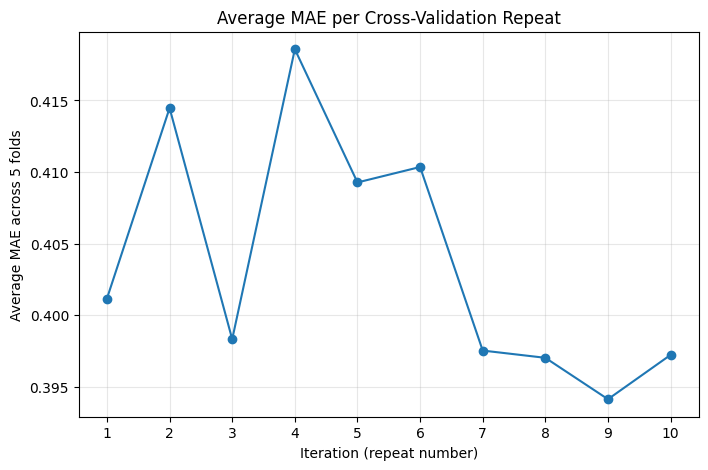

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import RepeatedKFold, cross_validate

SEED = 42
n_folds = 5
n_repeats = 10

reg = LinearRegression()
cv = RepeatedKFold(n_splits=n_folds, n_repeats=n_repeats, random_state=SEED)

score = cross_validate(reg, X=X, y=y, cv=cv, scoring='neg_mean_absolute_error')

# 50 individual MAE values (neg -> positive)
test_mae = np.abs(score['test_score'])

# Reshape to (n_repeats, n_folds) = (10, 5): each ROW is one repeat
mae_per_fold = test_mae.reshape(n_repeats, n_folds)

# Average across the 5 folds -> one value per repeat (10 values)
avg_mae_per_repeat = mae_per_fold.mean(axis=1)

for i, m in enumerate(avg_mae_per_repeat, start=1):
    print(f"Repeat {i:2d}: average MAE = {m:.4f}")

# --- Plot ---
iterations = np.arange(1, n_repeats + 1)   # x-axis: 1 to 10

plt.figure(figsize=(8, 5))
plt.plot(iterations, avg_mae_per_repeat, marker='o', linestyle='-')
plt.title('Average MAE per Cross-Validation Repeat')
plt.xlabel('Iteration (repeat number)')
plt.ylabel('Average MAE across 5 folds')
plt.xticks(iterations)
plt.grid(True, alpha=0.3)
plt.show()


A single 5-fold cross-validation splits the data into folds only once. Because that split is random, the resulting MAE depends on which samples happen to land in each fold. With a small dataset (200 samples), one "lucky" or "unlucky" split can give a misleadingly low or high error — the estimate is sensitive to the particular partitioning. Repeating the cross-validation 10 times (each repeat reshuffling the data before making new folds) produces 10 different estimates of the average MAE. This lets us:

Reduce the variance of the performance estimate by averaging over many splits, giving a more reliable measure of how the model generalizes.

Quantify the uncertainty — the spread (standard deviation) of the per-repeat MAE values tells us how stable the model's performance is with respect to the choice of train/validation split.